# Week 1 - Task 2
## Visual Analytics & Promotional Insights - Nova Mart

### Business Context & Objectives:
Our client, **Nova Mart**, a major retail chain in southern India, conducted massive promotional campaigns during **Diwali 2023** and **Sankranti 2024** across all 50 stores on their Nova-branded products.

In **Task 2**, our objective is to conduct visual exploratory data analysis and provide strategic business insights using rich visualizations (Bar charts, Pie charts, Heatmaps, Histograms, Line charts, and Scatter plots) to answer 7 key business questions for the *Sales Director*.


In [1]:
# ==============================================================================
# SETUP & DATA PREPARATION
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configure visualization styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

# 2. Load datasets from resources_2/datasets/
campaigns = pd.read_csv('resources_2/datasets/dim_campaigns.csv')
products = pd.read_csv('resources_2/datasets/dim_products.csv')
stores = pd.read_csv('resources_2/datasets/dim_stores.csv')
events = pd.read_csv('resources_2/datasets/fact_events.csv')

# 3. Merge dimension tables into the fact table
df = events.merge(campaigns, on='campaign_id', how='left') \
           .merge(products, on='product_code', how='left') \
           .merge(stores, on='store_id', how='left')

# 4. Compute financial and operational metrics:
# - Revenue Before & After Promo (Price * Quantity)
df['revenue_before'] = df['base_price(before_promo)'] * df['quantity_sold(before_promo)']
df['revenue_after'] = df['base_price(after_promo)'] * df['quantity_sold(after_promo)']

# - Incremental Sold Units (ISU) & Incremental Revenue (IR)
df['isu'] = df['quantity_sold(after_promo)'] - df['quantity_sold(before_promo)']
df['ir'] = df['revenue_after'] - df['revenue_before']

# 5. Display preview of prepared analytical dataset
print(f"Dataset successfully loaded & merged. Total records: {len(df):,} rows.")
df.head(3)

Dataset successfully loaded & merged. Total records: 1,500 rows.


,event_id,store_id,campaign_id,product_code,base_price(before_promo),quantity_sold(before_promo),promo_type,base_price(after_promo),quantity_sold(after_promo),campaign_name,start_date,end_date,product_name,category,city,revenue_before,revenue_after,isu,ir
0,8481be,STCHE-1,CAMP_DIW_01,P04,290,327.0,25% OFF,217,287,Diwali,12-11-2023,18-11-2023,Atliq_Farm_Chakki_Atta (1KG),Grocery & Staples,Chennai,94830.0,62279,-40.0,-32551.0
1,20618e,STCHE-3,CAMP_SAN_01,P04,370,379.0,BOGOF,185,1622,Sankranti,10-01-2024,16-01-2024,Atliq_Farm_Chakki_Atta (1KG),Grocery & Staples,Chennai,140230.0,300070,1243.0,159840.0
2,f30579,STBLR-9,CAMP_DIW_01,P02,860,337.0,33% OFF,576,488,Diwali,12-11-2023,18-11-2023,Atliq_Sonamasuri_Rice (10KG),Grocery & Staples,Bengaluru,289820.0,281088,151.0,-8732.0


---
### 1. Visualize the number of stores in each city. Identify the city with the most stores and explain the distribution of stores across other cities. How does the number of stores in Bengaluru compare with those in Hyderabad and Chennai?
*(Hint: Use a bar chart to visualize the number of stores by city)*


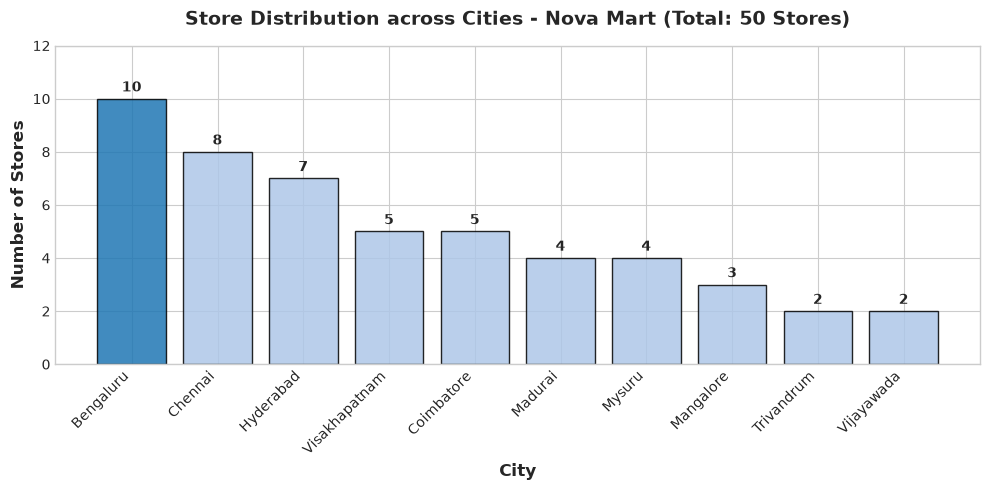

=== BUSINESS INSIGHTS - QUESTION 1 ===
1. City with the most stores: Bengaluru (10 stores).
2. Store Distribution: Major concentration is observed in Tier-1/metro cities (Bengaluru: 10, Chennai: 8, Hyderabad: 7), accounting for 50% (25 of 50) of all stores.
3. Comparison: Bengaluru has 25% more stores than Chennai (8 stores) and ~43% more stores than Hyderabad (7 stores).


In [2]:
# 1. Count unique stores in each city and sort in descending order
store_counts = stores['city'].value_counts().reset_index()
store_counts.columns = ['city', 'store_count']

# 2. Create Bar Chart visualization
plt.figure(figsize=(10, 5))
colors = ['#1f77b4' if city == 'Bengaluru' else '#aec7e8' for city in store_counts['city']]
bars = plt.bar(store_counts['city'], store_counts['store_count'], color=colors, edgecolor='black', alpha=0.85)

# 3. Annotate bar values on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.15, int(yval), ha='center', va='bottom', fontweight='bold')

plt.title('Store Distribution across Cities - Nova Mart (Total: 50 Stores)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('City', fontsize=12, fontweight='bold')
plt.ylabel('Number of Stores', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(store_counts['store_count']) + 2)
plt.tight_layout()
plt.show()

# 4. Display structured business insights
bengaluru_stores = stores[stores['city'] == 'Bengaluru']['store_id'].nunique()
chennai_stores = stores[stores['city'] == 'Chennai']['store_id'].nunique()
hyderabad_stores = stores[stores['city'] == 'Hyderabad']['store_id'].nunique()

print("=== BUSINESS INSIGHTS - QUESTION 1 ===")
print(f"1. City with the most stores: Bengaluru ({bengaluru_stores} stores).")
print(f"2. Store Distribution: Major concentration is observed in Tier-1/metro cities (Bengaluru: 10, Chennai: 8, Hyderabad: 7), accounting for 50% (25 of 50) of all stores.")
print(f"3. Comparison: Bengaluru has 25% more stores than Chennai ({chennai_stores} stores) and ~43% more stores than Hyderabad ({hyderabad_stores} stores).")

---
### 2. Analyze the total quantity sold after promotion for the Sankranti campaign across different product categories. What percentage does each category contribute to the overall sales, and what insights can be drawn from these contributions?
*(Hint: Use a pie chart to visualize percentage contribution of each category to the overall sales)*


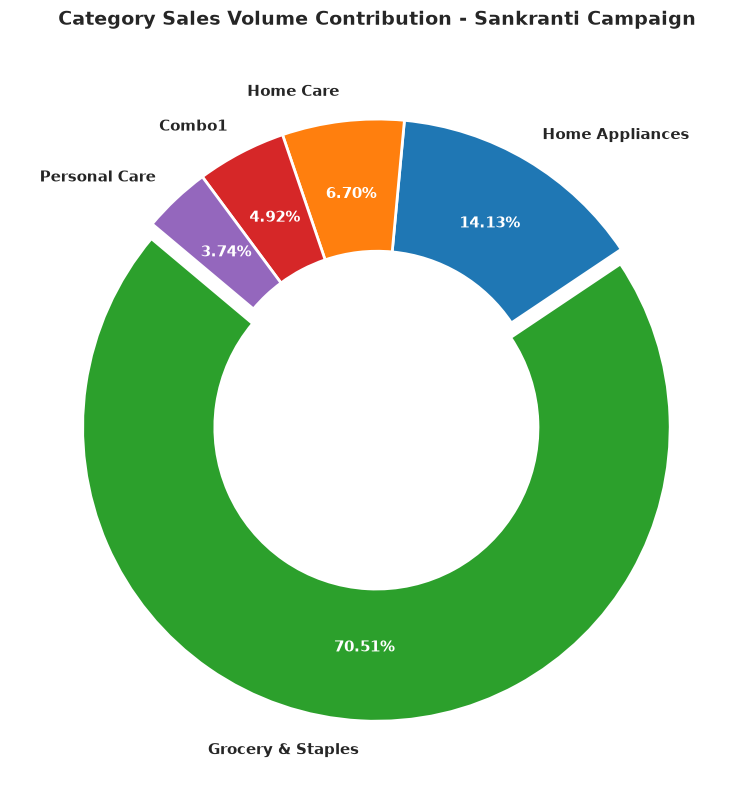

=== CATEGORY SALES CONTRIBUTION TABLE ===
                   Total_Units_Sold  Contribution_%
category                                           
Grocery & Staples            177724           70.51
Home Appliances               35610           14.13
Home Care                     16894            6.70
Combo1                        12411            4.92
Personal Care                  9430            3.74

=== BUSINESS INSIGHTS - QUESTION 2 ===
1. Grocery & Staples heavily dominates total volume, contributing 70.51% (177,724 units) of all units sold during Sankranti.
2. Home Appliances ranks 2nd with 14.13% (35,610 units), followed by Home Care (6.70%), Combo1 (4.92%), and Personal Care (3.74%).
3. Strategic Takeaway: The Sankranti festival drives massive consumer demand for essential household food items, making Grocery & Staples the primary volume magnet.


In [3]:
# 1. Filter records for the 'Sankranti' campaign
sankranti_df = df[df['campaign_name'] == 'Sankranti']

# 2. Aggregate total quantity sold after promotion by product category
category_sales = sankranti_df.groupby('category')['quantity_sold(after_promo)'].sum().sort_values(ascending=False)

# 3. Calculate percentage contribution for each category
category_pct = (category_sales / category_sales.sum()) * 100

# 4. Create Donut / Pie Chart visualization
plt.figure(figsize=(8, 8))
colors_pie = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#9467bd']
explode = [0.05, 0, 0, 0, 0]  # Highlight top contributing category

wedges, texts, autotexts = plt.pie(
    category_sales, 
    labels=category_sales.index, 
    autopct='%1.2f%%',
    startangle=140, 
    colors=colors_pie,
    explode=explode,
    pctdistance=0.75,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2)
)

plt.setp(autotexts, size=11, weight="bold", color="white")
plt.setp(texts, size=11, weight="bold")
plt.title('Category Sales Volume Contribution - Sankranti Campaign', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# 5. Display tabular summary and business insights
summary_q2 = pd.DataFrame({'Total_Units_Sold': category_sales, 'Contribution_%': category_pct.round(2)})
print("=== CATEGORY SALES CONTRIBUTION TABLE ===")
print(summary_q2.to_string())

print("\n=== BUSINESS INSIGHTS - QUESTION 2 ===")
print("1. Grocery & Staples heavily dominates total volume, contributing 70.51% (177,724 units) of all units sold during Sankranti.")
print("2. Home Appliances ranks 2nd with 14.13% (35,610 units), followed by Home Care (6.70%), Combo1 (4.92%), and Personal Care (3.74%).")
print("3. Strategic Takeaway: The Sankranti festival drives massive consumer demand for essential household food items, making Grocery & Staples the primary volume magnet.")

---
### 3. Examine the correlation between base price (after the promotion) and sales quantities (after the promotion). What insights can be drawn regarding the relationship between base price and sales quantities after the promotion?
*(Hint: Use heatmap to get the correlation)*


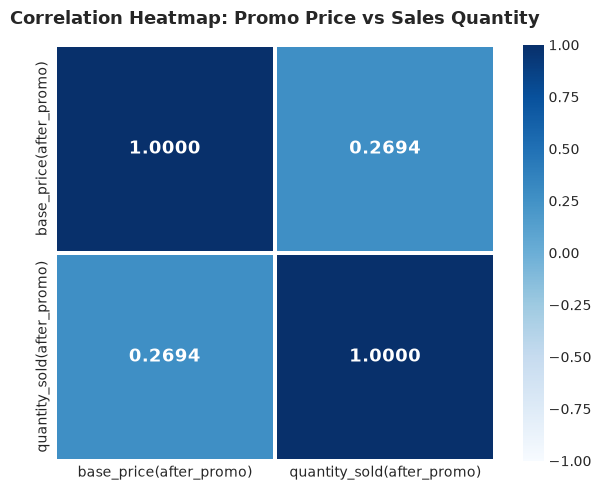

=== BUSINESS INSIGHTS - QUESTION 3 ===
1. Pearson Correlation Coefficient: 0.2694 (Weak positive correlation).
2. Business Interpretation: Promotional sales volume is not solely dictated by lower price points; high-ticket bundles (e.g., Combo packs) experienced high demand due to attractive cashback incentives (₹500 Cashback).
3. Promotional mechanics (e.g., BOGOF on mid-priced staples) generated substantial volume uplift, offsetting standard price sensitivity dynamics.


In [4]:
# 1. Compute correlation matrix between discounted base price and promotional sales quantities
price_qty_corr = df[['base_price(after_promo)', 'quantity_sold(after_promo)']].corr()

# 2. Create Correlation Heatmap visualization
plt.figure(figsize=(6, 5))
sns.heatmap(
    price_qty_corr, 
    annot=True, 
    fmt='.4f', 
    cmap='Blues', 
    vmin=-1, 
    vmax=1, 
    cbar=True,
    linewidths=1.5,
    annot_kws={"size": 13, "weight": "bold"}
)

plt.title('Correlation Heatmap: Promo Price vs Sales Quantity', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# 3. Display business insights
corr_val = price_qty_corr.loc['base_price(after_promo)', 'quantity_sold(after_promo)']
print("=== BUSINESS INSIGHTS - QUESTION 3 ===")
print(f"1. Pearson Correlation Coefficient: {corr_val:.4f} (Weak positive correlation).")
print("2. Business Interpretation: Promotional sales volume is not solely dictated by lower price points; high-ticket bundles (e.g., Combo packs) experienced high demand due to attractive cashback incentives (₹500 Cashback).")
print("3. Promotional mechanics (e.g., BOGOF on mid-priced staples) generated substantial volume uplift, offsetting standard price sensitivity dynamics.")

---
### 4. Analyze the distribution of quantity sold before the promotion for each product category (Grocery & Staples, Home Care, Personal Care, Home Appliances, etc.). What patterns or trends do you observe across these categories, and how could these insights inform future promotional strategies?
*(Hint: Use individual histograms to visualize the distribution)*


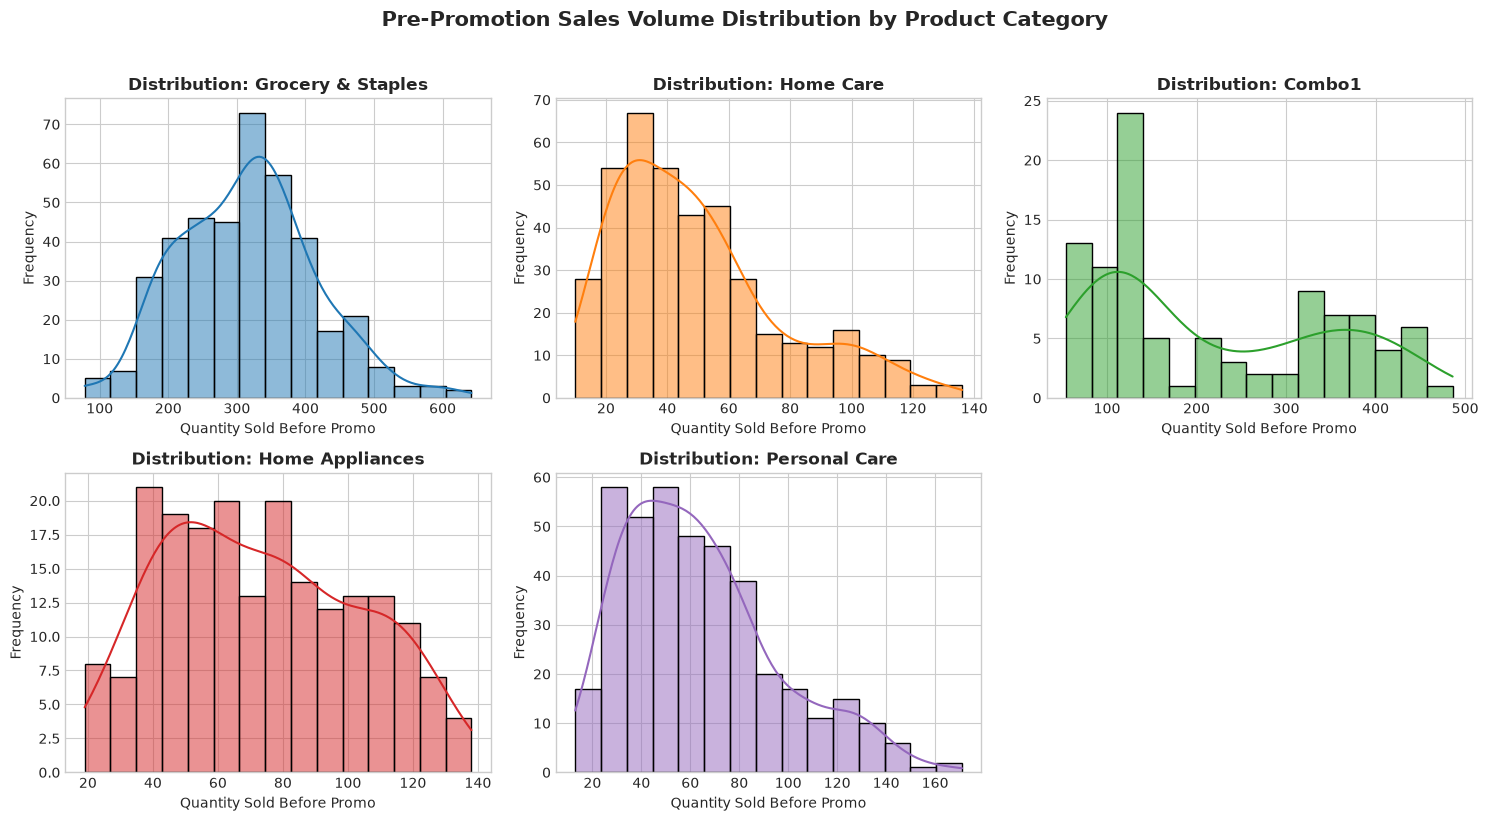

=== PRE-PROMOTION BASELINE SALES STATISTICS ===
                   count   mean    std   min    50%    max
category                                                  
Combo1             100.0  217.3  129.6  54.0  147.0  486.0
Grocery & Staples  400.0  314.8   99.0  78.0  317.0  642.0
Home Appliances    200.0   73.3   30.0  19.0   72.0  138.0
Home Care          400.0   49.6   27.3  10.0   43.0  136.0
Personal Care      400.0   63.8   31.2  13.0   58.0  171.0

=== BUSINESS INSIGHTS - QUESTION 4 ===
1. Distribution Patterns: Grocery & Staples has the highest baseline demand (mean: 314.8 units) with a normal distribution leaning towards high volumes.
2. Personal Care & Home Care exhibit lower baseline demand (mean: 50-64 units), while Combo1 exhibits wide bimodal variance.
3. Strategic Recommendations:
   - For Low Baseline Categories (Personal Care / Home Care): Deploy volume-incentive mechanics (e.g., BOGOF) to encourage consumer trial and stock-up behavior.
   - For Fast-Moving Categorie

In [5]:
# 1. Retrieve list of unique product categories
categories = df['category'].unique()

# 2. Create individual histograms in a 2x3 subplot layout
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()

palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 3. Plot histogram for each category
for i, cat in enumerate(categories):
    cat_data = df[df['category'] == cat]['quantity_sold(before_promo)']
    sns.histplot(cat_data, bins=15, kde=True, ax=axes[i], color=palette[i % len(palette)], edgecolor='black')
    axes[i].set_title(f'Distribution: {cat}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Quantity Sold Before Promo', fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)

# Remove unused 6th subplot
if len(categories) < len(axes):
    fig.delaxes(axes[-1])

plt.suptitle('Pre-Promotion Sales Volume Distribution by Product Category', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 4. Tabular summary statistics
stats_df = df.groupby('category')['quantity_sold(before_promo)'].describe().round(1)
print("=== PRE-PROMOTION BASELINE SALES STATISTICS ===")
print(stats_df[['count', 'mean', 'std', 'min', '50%', 'max']])

print("\n=== BUSINESS INSIGHTS - QUESTION 4 ===")
print("1. Distribution Patterns: Grocery & Staples has the highest baseline demand (mean: 314.8 units) with a normal distribution leaning towards high volumes.")
print("2. Personal Care & Home Care exhibit lower baseline demand (mean: 50-64 units), while Combo1 exhibits wide bimodal variance.")
print("3. Strategic Recommendations:")
print("   - For Low Baseline Categories (Personal Care / Home Care): Deploy volume-incentive mechanics (e.g., BOGOF) to encourage consumer trial and stock-up behavior.")
print("   - For Fast-Moving Categories (Grocery & Staples): Moderate discounts or bundle cashback suffice to drive incremental sales without unnecessary margin erosion.")

---
### 5. Analyze the incremental sold units percentage (ISU%) across various cities. Identify the city with the highest ISU% after the promotion and the city with the smallest change. What trends can be observed about the effectiveness of promotions in driving sales across these cities?
*(Hint: Use a line chart to visualize the ISU% comparison across cities)*


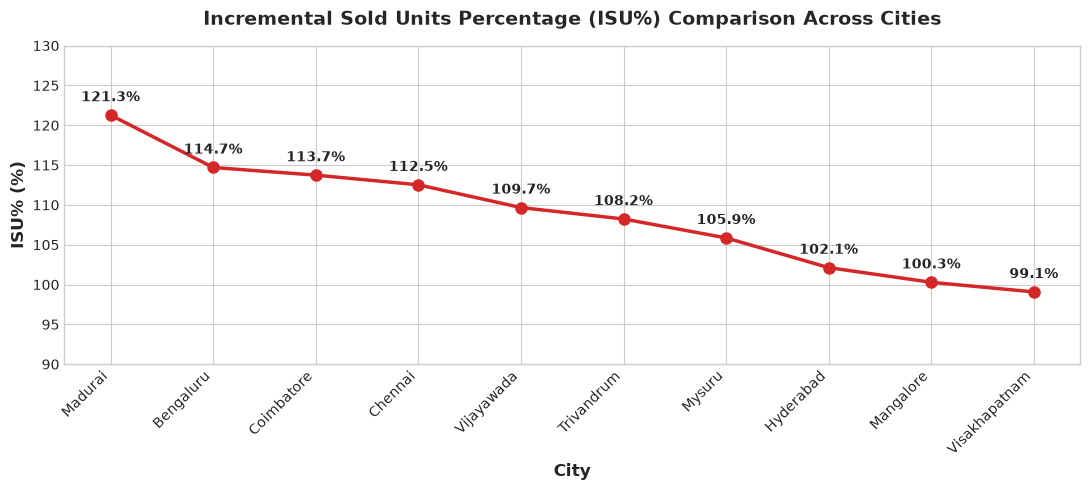

=== ISU% RANKINGS BY CITY ===
         city  total_qty_before  total_qty_after       ISU%
      Madurai           14086.0            31169 121.276445
    Bengaluru           48972.0           105141 114.696153
   Coimbatore           18200.0            38900 113.736264
      Chennai           39183.0            83273 112.523288
   Vijayawada            5297.0            11106 109.665849
   Trivandrum            4884.0            10170 108.230958
       Mysuru           18202.0            37470 105.856499
    Hyderabad           34335.0            69399 102.123198
    Mangalore            7454.0            14929 100.281728
Visakhapatnam           17037.0            33916  99.072607

=== BUSINESS INSIGHTS - QUESTION 5 ===
1. City with highest ISU%: Madurai (121.28%).
2. City with smallest change: Visakhapatnam (99.07%).
3. Regional Trends: Promotional effectiveness is universally robust, with all cities experiencing unit sales increases near or above 100% (doubling unit sales). Tier-2 ma

In [6]:
# 1. Aggregate pre- and post-promo sales quantities across cities
city_isu = df.groupby('city').agg(
    total_qty_before=('quantity_sold(before_promo)', 'sum'),
    total_qty_after=('quantity_sold(after_promo)', 'sum')
).reset_index()

# 2. Calculate ISU% formula: ((Qty_after - Qty_before) / Qty_before) * 100
city_isu['ISU%'] = (
    ((city_isu['total_qty_after'] - city_isu['total_qty_before']) / 
     city_isu['total_qty_before']) * 100
)

# 3. Sort cities by ISU% descending
city_isu_sorted = city_isu.sort_values(by='ISU%', ascending=False).reset_index(drop=True)

# 4. Create Line Chart visualization
plt.figure(figsize=(11, 5))
plt.plot(city_isu_sorted['city'], city_isu_sorted['ISU%'], marker='o', linewidth=2.5, markersize=8, color='#d62728')

# Annotate values above points
for i, row in city_isu_sorted.iterrows():
    plt.annotate(
        f"{row['ISU%']:.1f}%", 
        (row['city'], row['ISU%']),
        textcoords="offset points", 
        xytext=(0, 10), 
        ha='center', 
        fontweight='bold', 
        fontsize=10
    )

plt.title('Incremental Sold Units Percentage (ISU%) Comparison Across Cities', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('City', fontsize=12, fontweight='bold')
plt.ylabel('ISU% (%)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(90, 130)
plt.tight_layout()
plt.show()

# 5. Display tabular rankings and business insights
print("=== ISU% RANKINGS BY CITY ===")
print(city_isu_sorted[['city', 'total_qty_before', 'total_qty_after', 'ISU%']].to_string(index=False))

print("\n=== BUSINESS INSIGHTS - QUESTION 5 ===")
print(f"1. City with highest ISU%: {city_isu_sorted.iloc[0]['city']} ({city_isu_sorted.iloc[0]['ISU%']:.2f}%).")
print(f"2. City with smallest change: {city_isu_sorted.iloc[-1]['city']} ({city_isu_sorted.iloc[-1]['ISU%']:.2f}%).")
print("3. Regional Trends: Promotional effectiveness is universally robust, with all cities experiencing unit sales increases near or above 100% (doubling unit sales). Tier-2 markets like Madurai and Coimbatore show exceptionally strong promotional responsiveness.")

---
### 6. Analyze the relationship between incremental revenue and incremental sold units for different promotion types in Hyderabad. Which promotion type led to the highest incremental sold units, and which one generated the highest incremental revenue? What insights can you draw from the balance between the two metrics for this city?
*(Hint: Use a scatter plot to analyze the relationship)*


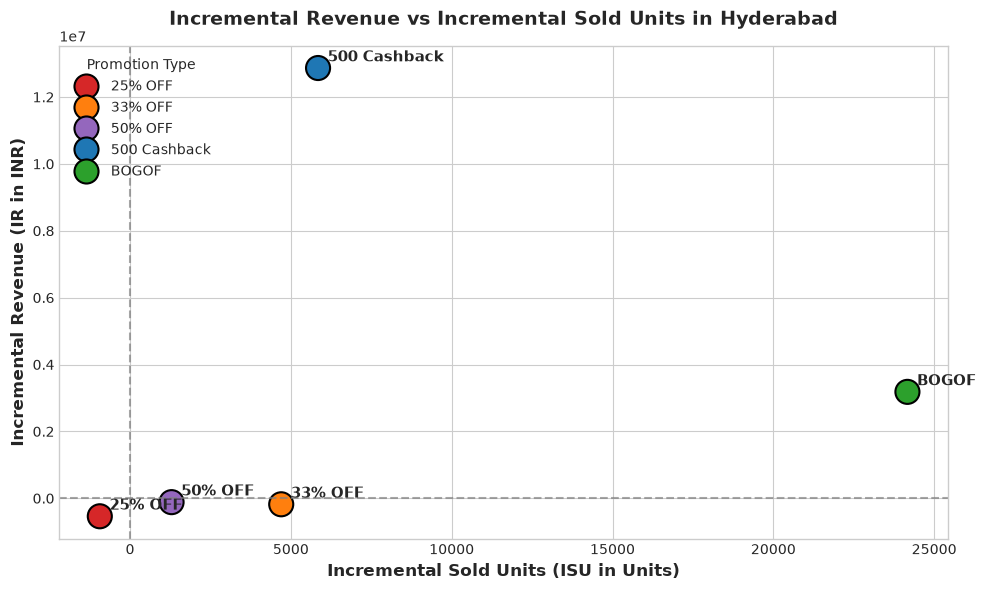

=== PROMOTION PERFORMANCE IN HYDERABAD ===
  promo_type  total_isu   total_ir
     25% OFF     -940.0  -537943.0
     33% OFF     4700.0  -179239.0
     50% OFF     1291.0  -115322.0
500 Cashback     5845.0 12866500.0
       BOGOF    24168.0  3182420.0

=== BUSINESS INSIGHTS - QUESTION 6 ===
1. Highest Incremental Sold Units: BOGOF (24,168 units).
2. Highest Incremental Revenue: 500 Cashback (₹12,866,500).
3. Strategic Trade-offs:
   - 'BOGOF' acts as the ultimate Volume Driver for inventory clearance and basket penetration.
   - '500 Cashback' serves as the primary Revenue & Margin Generator on high-ticket bundled items.
   - '25% OFF' proved counterproductive, resulting in negative growth across both volume and revenue.


In [7]:
# 1. Filter records for Hyderabad
hyd_df = df[df['city'] == 'Hyderabad']

# 2. Aggregate ISU and IR by promotion type
hyd_promo = hyd_df.groupby('promo_type').agg(
    total_isu=('isu', 'sum'),
    total_ir=('ir', 'sum')
).reset_index()

# 3. Create Scatter Plot visualization
plt.figure(figsize=(10, 6))
palette_promo = {'BOGOF': '#2ca02c', '500 Cashback': '#1f77b4', '33% OFF': '#ff7f0e', '50% OFF': '#9467bd', '25% OFF': '#d62728'}

sns.scatterplot(
    data=hyd_promo, 
    x='total_isu', 
    y='total_ir', 
    hue='promo_type', 
    palette=palette_promo,
    s=300, 
    edgecolor='black',
    linewidth=1.5
)

# Annotate text labels for each scatter point
for _, row in hyd_promo.iterrows():
    plt.text(
        row['total_isu'] + 300, 
        row['total_ir'] + 200000, 
        row['promo_type'], 
        fontsize=11, 
        fontweight='bold'
    )

plt.axhline(0, color='gray', linestyle='--', alpha=0.7)
plt.axvline(0, color='gray', linestyle='--', alpha=0.7)

plt.title('Incremental Revenue vs Incremental Sold Units in Hyderabad', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Incremental Sold Units (ISU in Units)', fontsize=12, fontweight='bold')
plt.ylabel('Incremental Revenue (IR in INR)', fontsize=12, fontweight='bold')
plt.legend(title='Promotion Type', loc='upper left')
plt.tight_layout()
plt.show()

# 4. Display tabular data and strategic insights
highest_isu_promo = hyd_promo.loc[hyd_promo['total_isu'].idxmax()]
highest_ir_promo = hyd_promo.loc[hyd_promo['total_ir'].idxmax()]

print("=== PROMOTION PERFORMANCE IN HYDERABAD ===")
print(hyd_promo.to_string(index=False))

print("\n=== BUSINESS INSIGHTS - QUESTION 6 ===")
print(f"1. Highest Incremental Sold Units: {highest_isu_promo['promo_type']} ({highest_isu_promo['total_isu']:,.0f} units).")
print(f"2. Highest Incremental Revenue: {highest_ir_promo['promo_type']} (₹{highest_ir_promo['total_ir']:,.0f}).")
print("3. Strategic Trade-offs:")
print("   - 'BOGOF' acts as the ultimate Volume Driver for inventory clearance and basket penetration.")
print("   - '500 Cashback' serves as the primary Revenue & Margin Generator on high-ticket bundled items.")
print("   - '25% OFF' proved counterproductive, resulting in negative growth across both volume and revenue.")

---
### 7. Analyze the revenue before and after promotions across different product categories in Bengaluru. What trends can be identified in the performance of each category, and how did promotions impact overall revenue in the city?
*(Hint: Use a vertical bar chart to compare the revenue before and after promotions)*


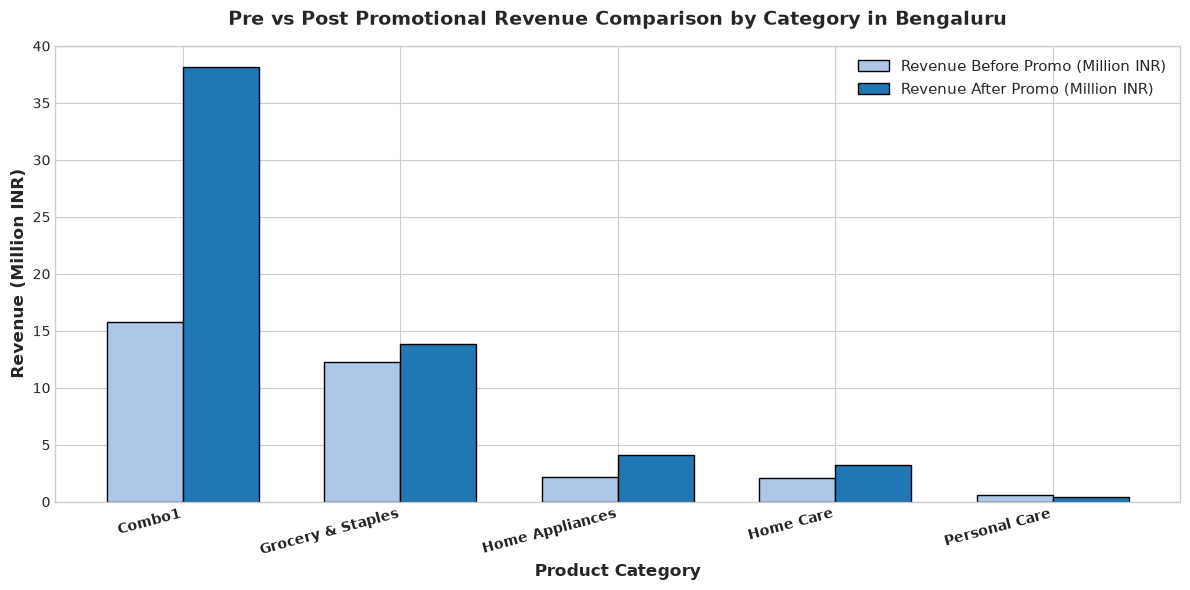

=== REVENUE COMPARISON TABLE IN BENGALURU ===
         category  rev_before  rev_after  revenue_growth   growth_%
           Combo1  15777000.0   38125000      22348000.0 141.649236
Grocery & Staples  12262460.0   13861259       1598799.0  13.038159
  Home Appliances   2188810.0    4122680       1933870.0  88.352575
        Home Care   2104460.0    3180020       1075560.0  51.108598
    Personal Care    576321.0     389629       -186692.0 -32.393753

=== BUSINESS INSIGHTS - QUESTION 7 ===
1. Total revenue in Bengaluru surged from ₹32.91M to ₹59.68M (+81.34%).
2. Combo1 emerged as the primary growth engine (+141.65% or +₹22.35M), followed by Home Appliances (+88.35%) and Home Care (+51.11%).
3. Personal Care recorded negative revenue growth (-32.39%), indicating that current promo mechanics failed to stimulate adequate volume to offset price reductions.


In [8]:
# 1. Filter records for Bengaluru
blr_df = df[df['city'] == 'Bengaluru']

# 2. Aggregate pre- and post-promo revenue by product category
blr_cat = blr_df.groupby('category').agg(
    rev_before=('revenue_before', 'sum'),
    rev_after=('revenue_after', 'sum')
).reset_index()

# 3. Calculate absolute revenue growth and percentage growth
blr_cat['revenue_growth'] = blr_cat['rev_after'] - blr_cat['rev_before']
blr_cat['growth_%'] = (blr_cat['revenue_growth'] / blr_cat['rev_before']) * 100

# 4. Create Grouped Vertical Bar Chart
x = np.arange(len(blr_cat['category']))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, blr_cat['rev_before'] / 1e6, width, label='Revenue Before Promo (Million INR)', color='#aec7e8', edgecolor='black')
plt.bar(x + width/2, blr_cat['rev_after'] / 1e6, width, label='Revenue After Promo (Million INR)', color='#1f77b4', edgecolor='black')

plt.title('Pre vs Post Promotional Revenue Comparison by Category in Bengaluru', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Product Category', fontsize=12, fontweight='bold')
plt.ylabel('Revenue (Million INR)', fontsize=12, fontweight='bold')
plt.xticks(x, blr_cat['category'], rotation=15, ha='right', fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# 5. Display comparative table and business insights
print("=== REVENUE COMPARISON TABLE IN BENGALURU ===")
print(blr_cat[['category', 'rev_before', 'rev_after', 'revenue_growth', 'growth_%']].to_string(index=False))

total_rev_before_blr = blr_cat['rev_before'].sum()
total_rev_after_blr = blr_cat['rev_after'].sum()
total_growth_blr = total_rev_after_blr - total_rev_before_blr
total_pct_blr = (total_growth_blr / total_rev_before_blr) * 100

print("\n=== BUSINESS INSIGHTS - QUESTION 7 ===")
print(f"1. Total revenue in Bengaluru surged from ₹{total_rev_before_blr/1e6:.2f}M to ₹{total_rev_after_blr/1e6:.2f}M (+{total_pct_blr:.2f}%).")
print("2. Combo1 emerged as the primary growth engine (+141.65% or +₹22.35M), followed by Home Appliances (+88.35%) and Home Care (+51.11%).")
print("3. Personal Care recorded negative revenue growth (-32.39%), indicating that current promo mechanics failed to stimulate adequate volume to offset price reductions.")